# Plot tracer surface fluxes

In [1]:
import xarray as xr

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
from roms_tools import Grid

In [4]:
grid_file = "roms_marbl_dic/expCTRL/pacmed12_grd.nc"
grid = Grid.from_file(grid_file, theta_s=6.0, theta_b=6.0, hc=250.0, N=100)

2026-07-10 01:41:13 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 6.0, theta_b = 6.0, hc = 250.0 ===
2026-07-10 01:41:13 - INFO - Total time: 0.003 seconds
2026-07-10 01:41:13 - INFO - ================================================================================================


In [5]:
ds = xr.open_dataset("INPUT/roms_tracer_surf_flux_2000.nc")

In [6]:
ds0 = ds.isel(time=0).compute()

In [7]:
def _add_coastlines_and_gridlines(ax):    
    # Add coastlines and land
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor='lightgray')    
    
    # Gridlines with labels only on left and bottom
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        x_inline=False,
        y_inline=False
    )
    gl.top_labels = False
    gl.right_labels = False

In [18]:
def plot_surface_flux(flux, title="Surface forcing", three_colorbars=False):
    # Convert units
    flux = flux.where(grid.ds.mask_rho)/1000*3600*24*365.25  # mmol/m2/s -> mol/m2/yr
    vmax = flux.max().values
    print(f"max: {vmax}")

    if three_colorbars:
        fig = plt.figure(figsize=(13, 5))
    else:
        fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))

    # Main plot
    p1 = ax.pcolormesh(
        grid.ds["lon_rho"],
        grid.ds["lat_rho"],
        flux,
        vmin=0, vmax=vmax,
        cmap="Reds",
        transform=ccrs.PlateCarree(),
    )

    # Set extent
    lon_min, lon_max = -93, 112
    lat_min, lat_max = ax.get_extent(crs=ccrs.PlateCarree(central_longitude=180))[2:]
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree(central_longitude=180))
    ax.set_title(title)
    _add_coastlines_and_gridlines(ax)

    # Colorbars
    if three_colorbars:
        # Positions for the 3 colorbars
        positions = [
            [0.8, 0.15, 0.02, 0.7],  # original
            [0.88, 0.15, 0.02, 0.7], # +1 order
            [0.96, 0.15, 0.02, 0.7], # +2 orders
        ]
        # Max values for each colorbar
        vmaxs = [vmax, vmax*10, vmax*100]

        for pos, vmax in zip(positions, vmaxs):
            cbar_ax = fig.add_axes(pos)
            # Create a ScalarMappable for each colorbar
            from matplotlib.cm import ScalarMappable
            from matplotlib.colors import Normalize
            sm = ScalarMappable(cmap="Reds", norm=Normalize(vmin=0, vmax=vmax))
            sm.set_array([])
            fig.colorbar(sm, cax=cbar_ax, orientation="vertical", label=f"mol/m$^2$/yr")
    else:
        cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
        fig.colorbar(p1, cax=cbar_ax, orientation="vertical", label=r"mol/m$^2$/yr")

    return fig

max: 0.4461116650088634


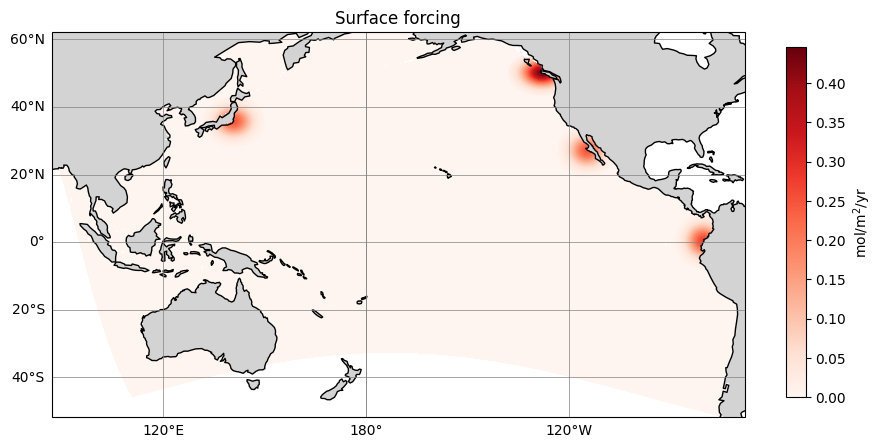

In [19]:
fig = plot_surface_flux(ds0.JP10 + ds0.VI10 + ds0.BC10 + ds0.EC10)

max: 4.461116650088635


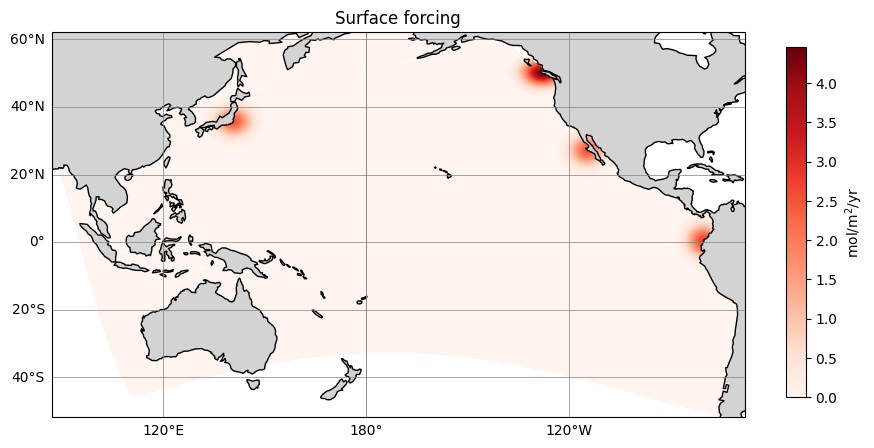

In [20]:
fig = plot_surface_flux(ds0.JP7 + ds0.VI7 + ds0.BC7 + ds0.EC7)

max: 44.61116650088634


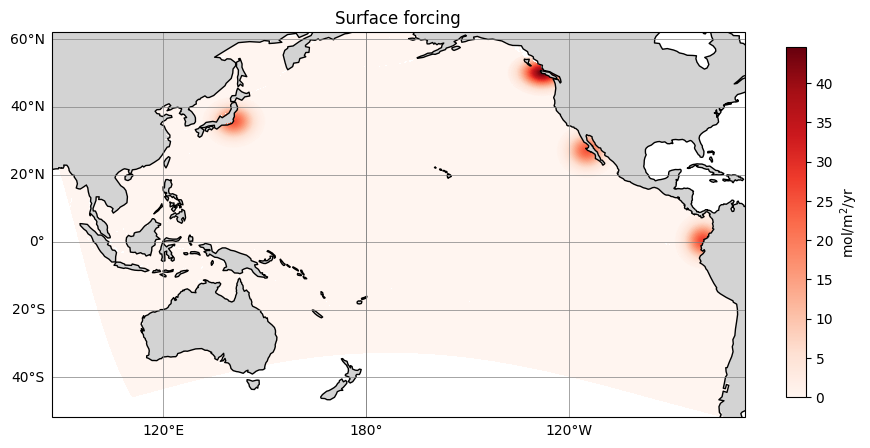

In [21]:
fig = plot_surface_flux(ds0.JP8 + ds0.VI8 + ds0.BC8 + ds0.EC8)

max: 0.4461116650088634


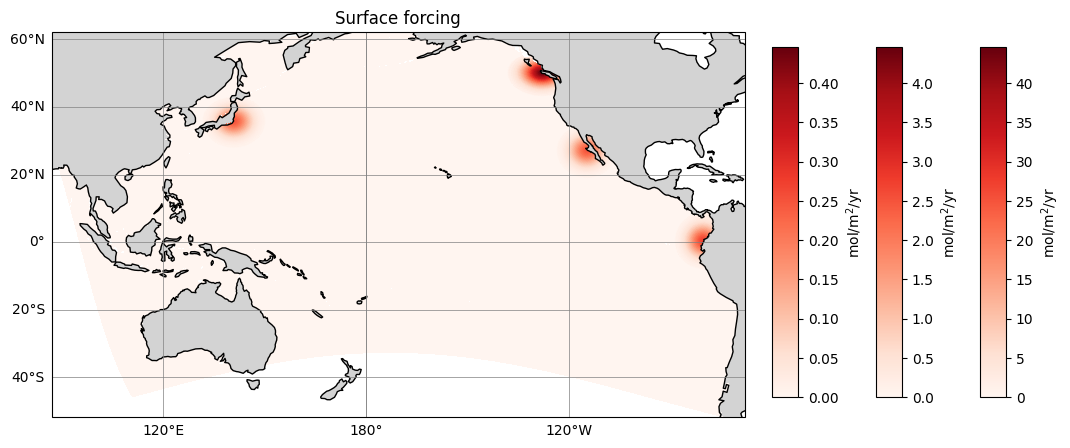

In [22]:
fig = plot_surface_flux(ds0.JP10 + ds0.VI10 + ds0.BC10 + ds0.EC10, three_colorbars=True)

In [23]:
fig.savefig(
    "figures/surface_forcing.png",
    dpi=300,
    bbox_inches="tight",
)

max: 24.823212057156248


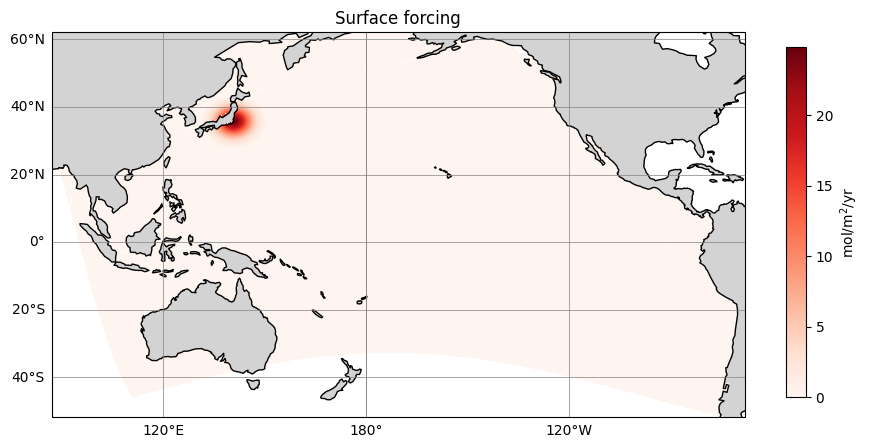

In [24]:
fig = plot_surface_flux(ds0.JP8)

max: 44.61116650088634


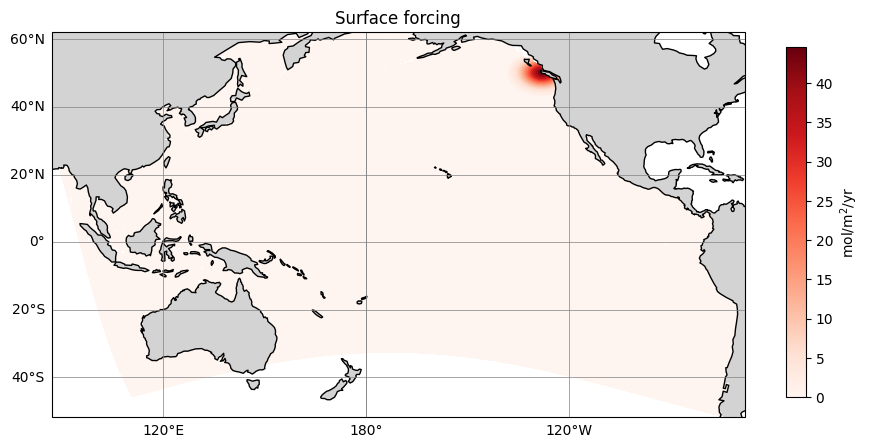

In [25]:
fig = plot_surface_flux(ds0.VI8)

max: 24.608789902223492


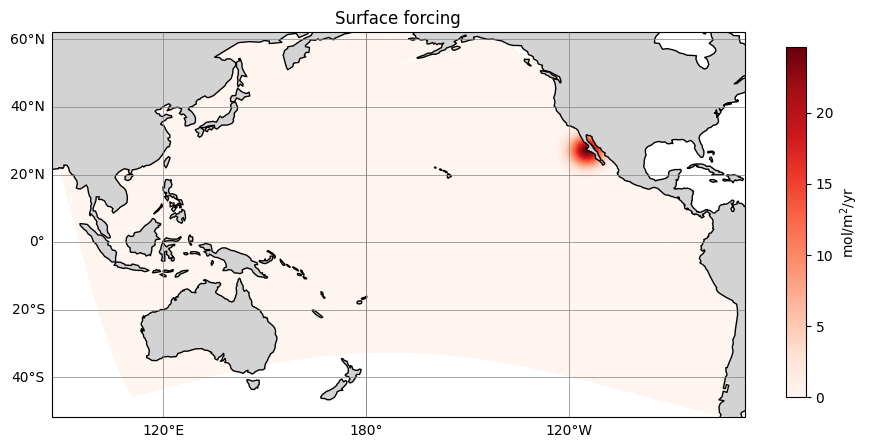

In [26]:
fig = plot_surface_flux(ds0.BC8)

max: 27.168163907636334


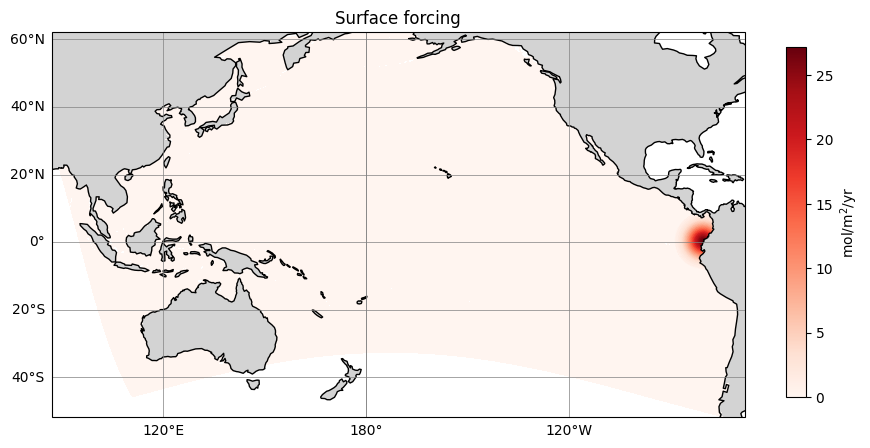

In [27]:
fig = plot_surface_flux(ds0.EC8)